## text-specific analysis 

Generating basic info of `.rft` documents separated by month and year. Generated data is in `data.json` file.

In [1]:
import os
from striprtf.striprtf import rtf_to_text
from classla import Pipeline
import classla
import json
import re
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
#import nltk

In [5]:
# Giving unique names to the RTF files

import os

root_dir = "../Data"  # glavna mapa
counter = 1

for year_folder in os.scandir(root_dir):
    if year_folder.is_dir():
        for month_folder in os.scandir(year_folder.path):
            if month_folder.is_dir():
                files = [f for f in os.listdir(month_folder.path) if os.path.isfile(os.path.join(month_folder.path, f))]

                for file in files:
                    old_path = os.path.join(month_folder.path, file)
                    _, ext = os.path.splitext(file)
                    new_file = f"{counter}{ext}"
                    new_path = os.path.join(month_folder.path, new_file)

                    # Če novo ime že obstaja, išči naslednje prosto ime
                    while os.path.exists(new_path):
                        counter += 1
                        new_file = f"{counter}{ext}"
                        new_path = os.path.join(month_folder.path, new_file)

                    os.rename(old_path, new_path)
                    #print(f"Renamed: {old_path} -> {new_path}")
                    counter += 1

In [4]:
#nltk.download("punkt")
classla.download("sl")
nlp = Pipeline("sl", processors="tokenize")
path = "../Data/"
subfolders_year = [f.path for f in os.scandir(path) if f.is_dir()]

2025-05-05 21:38:11 INFO: Downloading these customized packages for language: sl (Slovenian)...
| Processor | Package  |
------------------------
| tokenize  | standard |
| pos       | standard |
| lemma     | standard |
| depparse  | standard |
| ner       | standard |
| pretrain  | standard |

2025-05-05 21:38:13 INFO: File exists: C:\Users\mihal\classla_resources\sl\pos\standard.pt.
2025-05-05 21:38:13 INFO: File exists: C:\Users\mihal\classla_resources\sl\lemma\standard.pt.
2025-05-05 21:38:13 INFO: File exists: C:\Users\mihal\classla_resources\sl\depparse\standard.pt.
2025-05-05 21:38:13 INFO: File exists: C:\Users\mihal\classla_resources\sl\ner\standard.pt.
2025-05-05 21:38:13 INFO: File exists: C:\Users\mihal\classla_resources\sl\pretrain\standard.pt.
2025-05-05 21:38:13 INFO: Finished downloading models and saved to C:\Users\mihal\classla_resources.
2025-05-05 21:38:13 INFO: Loading these models for language: sl (Slovenian):
| Processor | Package  |
------------------------
| t

In [ ]:
# Not working or it takes too long (tried after unique renaming of rtf files)

document_dict = {}
date_pattern = r"(\d{1,2})\. (\d{1,2})\. (\d{4})"

for folder_year in subfolders_year:
    folder_year_name = os.path.basename(folder_year)
    subfolders_month = [f.path for f in os.scandir(folder_year) if f.is_dir()]
    document_dict[folder_year_name] = {
        "months": len(subfolders_month),
        "sentence_count": 0,
        "word_count": 0,
        "months_data": {}
    }
    for folder_month in subfolders_month:
        folder_month_name = os.path.basename(folder_month)
        files = [f for f in os.listdir(folder_month)]
        document_dict[folder_year_name]["months_data"][folder_month_name] = {
            "files": len(files),
            "sentence_count": 0,
            "word_count": 0,
            "file_data": {}
        }

        for file in files:
            with open(os.path.join(folder_month, file), "r", encoding="utf-8") as f:
                file_name = os.path.basename(file)
                rtf_content = f.read()
                plain_text = rtf_to_text(rtf_content)
                plain_text = re.sub(r"\s+", " ", plain_text).strip()
                plain_text = plain_text.replace("\u0000", "")
                modified_text = re.sub(date_pattern, r"\1[PERIOD] \2[PERIOD] \3", plain_text)

                # Tokenize plain text into sentences
                #sentences = nltk.tokenize.sent_tokenize(plain_text, language="sl")
                doc = nlp(modified_text)
                sentences = [sentence.text for sentence in doc.sentences if sentence.text is not None]
                sentences = [s.replace("[PERIOD]", ".") for s in sentences]
                

                document_dict[folder_year_name]["months_data"][folder_month_name]["file_data"][file_name] = {
                    "content": plain_text,
                    "word_count": len(plain_text.split()),
                    "char_count": len(plain_text),
                    "sentence_count": len(sentences),
                    "sentences": sentences
                }

                document_dict[folder_year_name]["months_data"][folder_month_name]["sentence_count"] += len(sentences)
                document_dict[folder_year_name]["months_data"][folder_month_name]["word_count"] += len(plain_text.split())

                document_dict[folder_year_name]["sentence_count"] += len(sentences)
                document_dict[folder_year_name]["word_count"] += len(plain_text.split())

        document_dict[folder_year_name]
                

with open("data.json", "w", encoding="utf-8") as f:
    json.dump(document_dict, f, ensure_ascii=False, indent=4)

: 

Read RTF documents in `data.json` file to `Pandas DataFrame`.

In [ ]:
# Read JSON
with open("data.json", "r", encoding="utf-8") as f:
    document_dict = json.load(f)
data = document_dict

records = []
for year in ["promet_2022", "promet_2023", "promet_2024"]:
    for month in document_dict[year]["months_data"].keys():
        month_data = document_dict[year]["months_data"][month]
        file_data_dict = month_data["file_data"]

        # Create a list of flattened records
        for file_name, file_details in file_data_dict.items():
            record = {
                # File-specific fields
                "year": year,
                "month": month,
                "file_name": file_name,
                "content": file_details["content"],
                "file_word_count": file_details["word_count"],
                "file_char_count": file_details["char_count"],
                "file_sentence_count": file_details["sentence_count"],
                "sentences": file_details["sentences"],
                
                # Month-specific fields
                "month_files": month_data["files"],
                "month_sentence_count": month_data["sentence_count"],
                "month_word_count": month_data["word_count"],

                # Year-specific fields
                "months": document_dict[year]["months"],
                "year_sentence_count": document_dict[year]["sentence_count"],
                "year_word_count": document_dict[year]["word_count"]
            }

            # Add datetime parsing
            content_text = file_details["content"]
            match = re.search(r"Prometne informacije\s+(\d{1,2}\.\s*\d{1,2}\.\s*\d{4})\s+(\d{1,2}\.\d{2})", content_text)
            if match:
                date_part = match.group(1).replace(" ", "") 
                time_part = match.group(2)                
                datetime_str = f"{date_part} {time_part}"
                try:
                    parsed_datetime = datetime.strptime(datetime_str, "%d.%m.%Y %H.%M")
                except ValueError:
                    parsed_datetime = None
            else:
                parsed_datetime = None
            record["datetime"] = parsed_datetime

            records.append(record)

# Convert to DataFrame
RTFS = pd.DataFrame(records)
RTFS.head()

28037


In [6]:
# Saving RTFS to CSV

RTFS_reduced = RTFS[["file_name", "content", "datetime"]]
RTFS_reduced["file_name"] = range(1, len(RTFS) + 1) # Unique file names
RTFS_reduced.to_csv("rtfs_reduced.csv", index=False, encoding='utf-8')

C:\Users\mihal\AppData\Local\Temp\ipykernel_15404\409079477.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RTFS_reduced["file_name"] = range(1, len(RTFS) + 1) # Unique file names


Preprocess report data from `traffic_reports_2022_2023_2024.xlsx`.

In [7]:
# Read the "traffic_reports_2022_2023_2024.xlsx" to Pandas DataFrame

path = "../Data/traffic_reports_2022_2023_2024.xlsx"
years = [2022, 2023, 2024]
REPORTS = {}

def clean_cell(val):
    if isinstance(val, str):
        val = re.sub(r'<strong>.*?</strong>', '', val, flags=re.DOTALL)  # removes <strong>...</strong>
        val = re.sub(r"<.*?>", "", val) # removes all HTML tags
        val = re.sub(r'"', '', val) # removes double quotes
        val = val.strip() # removes spaces             
    return val

for year in years:
    REPORTS[year] = pd.read_excel(path, sheet_name=str(year))

    "Some data cleaning and preprocessing"

    # Drop 100% empty columns A2 and C1
    REPORTS[year].drop(columns=["A2", "C1"], inplace=True)

    # Drop English columns
    REPORTS[year].drop(columns=["B2", "C2"], inplace=True)

    # Drop useless columns (report's id, report's author, all titles)
    REPORTS[year].drop(columns=["LegacyId", "Operater", "TitlePomembnoSLO", "TitleNesreceSLO", "TitleZastojiSLO", "TitleVremeSLO", "TitleOvireSLO","TitleDeloNaCestiSLO", "TitleOpozorilaSLO", "TitleMednarodneInformacijeSLO", "TitleSplosnoSLO"], inplace=True)

    # Clean up text values
    REPORTS[year] = REPORTS[year].map(clean_cell)

REPORTS[2022].head()

,Datum,A1,B1,ContentPomembnoSLO,ContentNesreceSLO,ContentZastojiSLO,ContentVremeSLO,ContentOvireSLO,ContentDeloNaCestiSLO,ContentOpozorilaSLO,ContentMednarodneInformacijeSLO,ContentSplosnoSLO
0,2022-01-01 00:07:07,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN
1,2022-01-01 00:07:29,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN
2,2022-01-01 00:07:30,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN
3,2022-01-01 00:07:36,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN
4,2022-01-01 00:16:26,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN


Visualize new preprocessed report from `traffic_reports_2022_2023_2024.xlsx`.

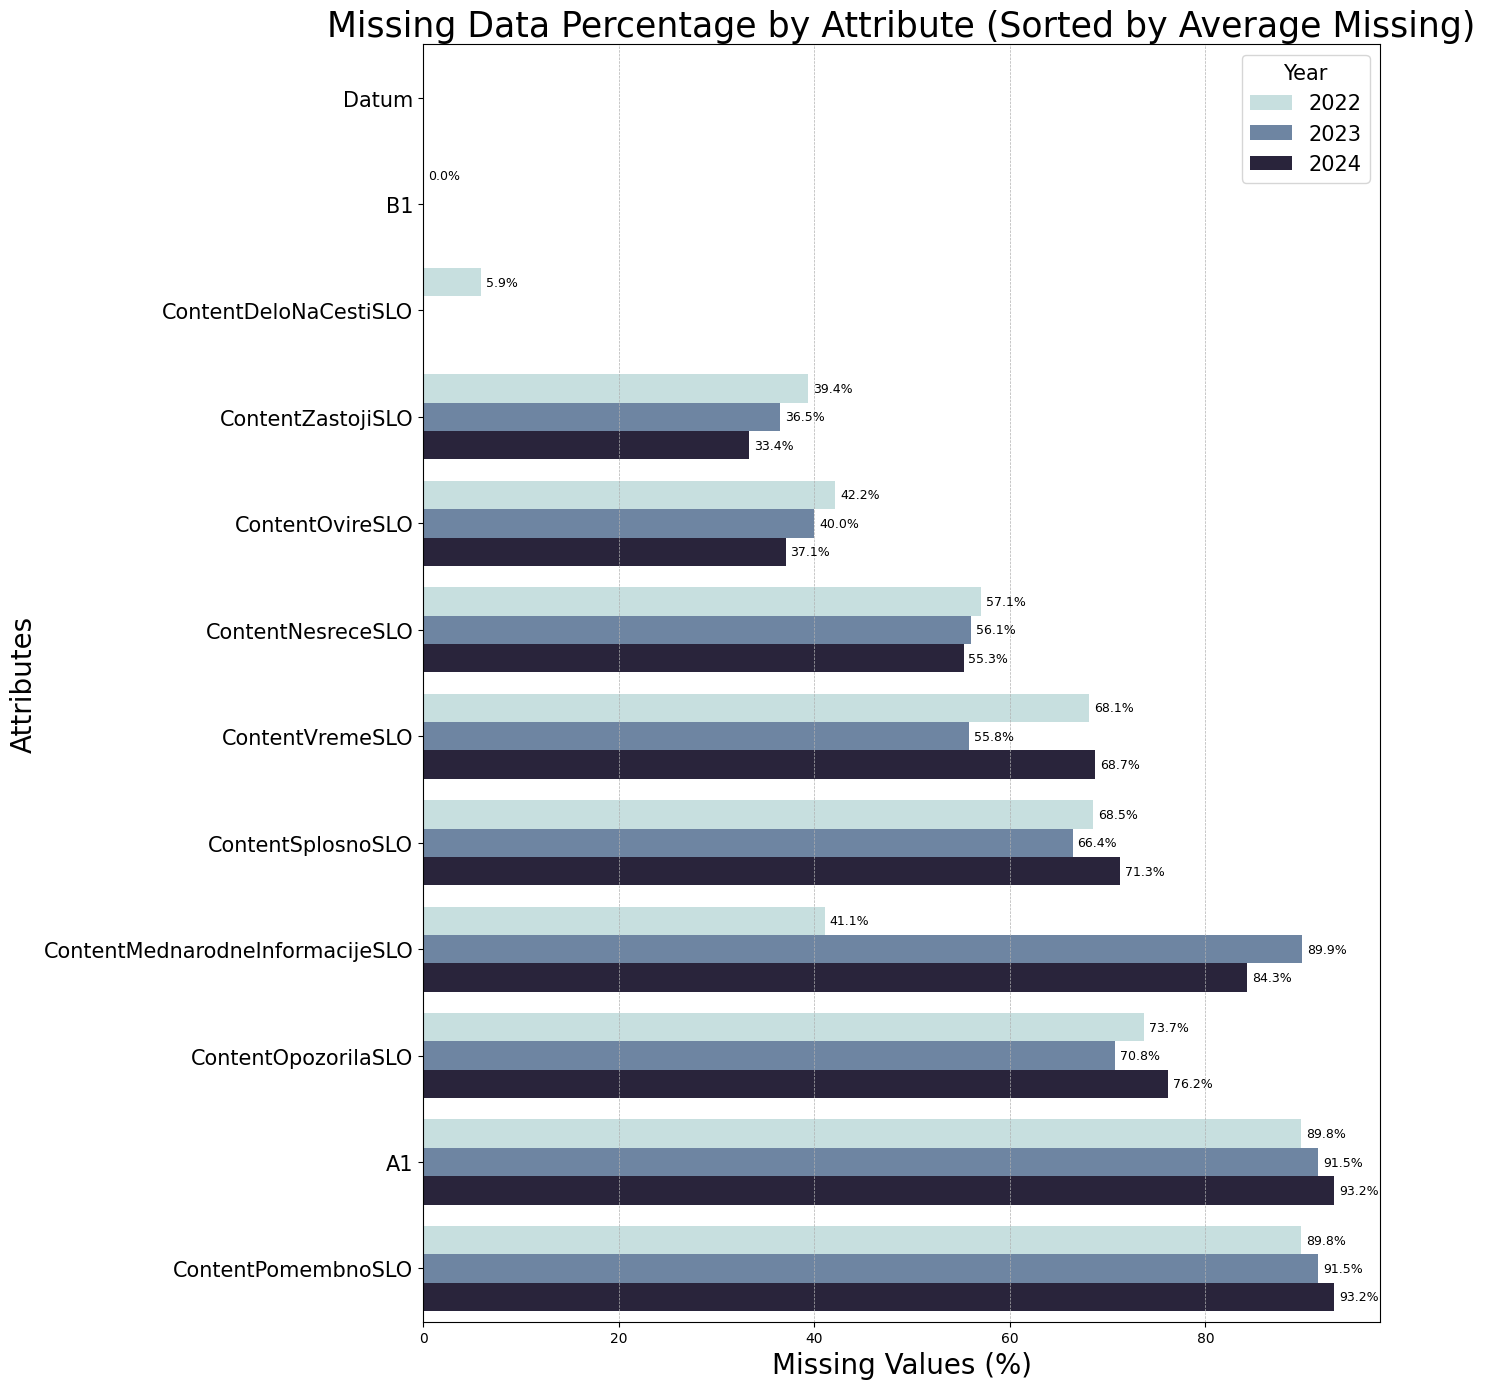

In [24]:
missing_data = {}

for year in years:
    missing_percent = REPORTS[year].isnull().mean() * 100
    missing_data[year] = missing_percent
df_missing = pd.DataFrame(missing_data)
df_missing["Average Missing %"] = df_missing.mean(axis=1)
df_missing = df_missing.sort_values("Average Missing %", ascending=True)

df_missing_melted = df_missing.drop(columns="Average Missing %").reset_index().melt(
    id_vars="index", var_name="Year", value_name="Missing %"
)
plt.figure(figsize=(14, 14))
ax = sns.barplot(
    data=df_missing_melted,
    y="index", x="Missing %",
    hue="Year", palette="ch:start=.2,rot=-.3"
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5,
            p.get_y() + p.get_height() / 2.,
            f'{width:.1f}%',
            ha="left", va="center", fontsize=9
        )

plt.yticks(fontsize=15)
plt.xlabel("Missing Values (%)", fontsize=20)
plt.ylabel("Attributes", fontsize=20)
plt.title("Missing Data Percentage by Attribute (Sorted by Average Missing)", fontsize=25)
plt.legend(title="Year", fontsize=15, title_fontsize=15, loc="best")
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

Link each report from `traffic_reports_2022_2023_2024.xlsx` to corresponding RTF document.

In [12]:
# For each report, find corresponding RTF file

RTFS_reduced = RTFS_reduced.sort_values("datetime").reset_index(drop=True)
for year in years:
    REPORTS[year]["RTF_file_name"] = None  # New column for RTF file names
    
    for index, row in REPORTS[year].iterrows():
        report_date = datetime.strptime(str(row["Datum"]), "%Y-%m-%d %H:%M:%S")

        # Find first RTF document with its datetime after the current report's datetime
        match = RTFS_reduced[RTFS_reduced["datetime"] >= report_date]
        
        if not match.empty:
            matched_file = match.iloc[0]["file_name"]  # Get the first match
        else:
            matched_file = None  # No match found

        REPORTS[year].at[index, "RTF_file_name"] = matched_file

In [13]:
# Remove report data without corresponding RTF file name

for year in years:

    # There are 5 reports without RTF file (last 5 reports from year 2024) due to no RTF data from 2025
    print(REPORTS[year][REPORTS[year]["RTF_file_name"].isna()])

    # Remove rows
    REPORTS[year] = REPORTS[year][REPORTS[year]["RTF_file_name"].notna()].reset_index(drop=True)

Empty DataFrame
Columns: [Datum, A1, B1, ContentPomembnoSLO, ContentNesreceSLO, ContentZastojiSLO, ContentVremeSLO, ContentOvireSLO, ContentDeloNaCestiSLO, ContentOpozorilaSLO, ContentMednarodneInformacijeSLO, ContentSplosnoSLO, RTF_file_name]
Index: []
Empty DataFrame
Columns: [Datum, A1, B1, ContentPomembnoSLO, ContentNesreceSLO, ContentZastojiSLO, ContentVremeSLO, ContentOvireSLO, ContentDeloNaCestiSLO, ContentOpozorilaSLO, ContentMednarodneInformacijeSLO, ContentSplosnoSLO, RTF_file_name]
Index: []
Empty DataFrame
Columns: [Datum, A1, B1, ContentPomembnoSLO, ContentNesreceSLO, ContentZastojiSLO, ContentVremeSLO, ContentOvireSLO, ContentDeloNaCestiSLO, ContentOpozorilaSLO, ContentMednarodneInformacijeSLO, ContentSplosnoSLO, RTF_file_name]
Index: []


In [14]:
# Save new reports data to one CSV file

all_reports = pd.concat([REPORTS[year] for year in years], ignore_index=True)
all_reports.to_csv("traffic_reports_linked.csv", index=False, encoding='utf-8')

In [15]:
# Final form of report data

REPORTS_linked = pd.read_csv("traffic_reports_linked.csv", encoding='utf-8')
REPORTS_linked.head()

,Datum,A1,B1,ContentPomembnoSLO,ContentNesreceSLO,ContentZastojiSLO,ContentVremeSLO,ContentOvireSLO,ContentDeloNaCestiSLO,ContentOpozorilaSLO,ContentMednarodneInformacijeSLO,ContentSplosnoSLO,RTF_file_name
0,2022-01-01 00:07:07,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN,3871
1,2022-01-01 00:07:29,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN,3871
2,2022-01-01 00:07:30,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN,3871
3,2022-01-01 00:07:36,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN,3871
4,2022-01-01 00:16:26,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,NaN,NaN,Ponekod po Sloveniji megla v pasovih zmanjšuje...,NaN,Na primorski avtocesti je ponovno odprt priklj...,Po Sloveniji velja med prazniki omejitev za to...,NaN,NaN,3871
